In [3]:
!pip install ccxt xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached ccxt-4.5.52-py2.py3-none-any.whl.metadata (143 kB)
  Using cached aiohttp-3.13.5-cp314-cp314-win_amd64.whl.metadata (8.4 kB)
  Using cached aiodns-4.0.0-py3-none-any.whl.metadata (7.7 kB)
  Using cached yarl-1.23.0-cp314-cp314-win_amd64.whl.metadata (82 kB)
   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/6.6 MB 6.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.1/6.6 MB 9.7 MB/s eta 0:00:01
   --------------------------------- ------ 5.5/6.6 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------  6.6/6.6 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 6.6/6.6 MB 8.7 MB/s  0:00:00

   ----------------------------------------  0/10 [propcache]
   ---- -----------------------------------  1/10 [multidict]
   -------- -------------------------------  2/10 [frozenlist]
   -------- -


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import ccxt
import time
from datetime import datetime, timezone, timedelta

print("⏳ Запускаем машину времени (Качаем 3 года истории 15m)...")

exchange = ccxt.bybit({'enableRateLimit': True})
symbol = 'BTC/USDT'
timeframe = '15m' 

days_back = 1095 # 3 года
# Используем timezone.utc, чтобы Питон не ругался
now_utc = datetime.now(timezone.utc)
since_dt = now_utc - timedelta(days=days_back)
since = exchange.parse8601(since_dt.strftime('%Y-%m-%dT%H:%M:%SZ'))

all_ohlcv = []
limit = 1000 

while True:
    try:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since, limit)
        if len(ohlcv) == 0: 
            break
            
        all_ohlcv.extend(ohlcv)
        since = ohlcv[-1][0] + 1
        
        # Останавливаемся, только если дошли до реального текущего времени
        if since >= exchange.milliseconds():
            break
            
        time.sleep(0.5) 
        
    except Exception as e:
        print(f"⚠️ Ошибка: {e}, ждем 5 секунд...")
        time.sleep(5)

df_history = pd.DataFrame(all_ohlcv, columns=['time', 'open', 'high', 'low', 'close', 'volume'])
df_history['time'] = pd.to_datetime(df_history['time'], unit='ms')
df_history.set_index('time', inplace=True)

print(f"✅ Успешно скачано {len(df_history)} свечей!")
print(f"Период: с {df_history.index.min()} по {df_history.index.max()}")
df_history.to_csv("btc_3_years_15m.csv")

⏳ Запускаем машину времени (Качаем 3 года истории 15m)...
✅ Успешно скачано 105120 свечей!
Период: с 2023-05-08 20:30:00 по 2026-05-07 20:15:00


In [7]:
import pandas as pd
import numpy as np

print("🧠 1. ГЕНЕРАЦИЯ SMC ФИЧЕЙ (БЕЗ сторонних библиотек)...")
df = pd.read_csv("btc_3_years_15m.csv", index_col='time', parse_dates=True)

candle_range = df['high'] - df['low'] + 1e-9
df['rvol'] = df['volume'] / (df['volume'].rolling(50).mean() + 1e-9)

# --- ПИШЕМ СВОЙ БОЛЛИНДЖЕР ---
basis = df['close'].rolling(window=20).mean()
dev = df['close'].rolling(window=20).std()
upper_bb = basis + 2 * dev
lower_bb = basis - 2 * dev
df['bb_width'] = (upper_bb - lower_bb) / (basis + 1e-9) * 100

df['fvg_bull'] = np.where(df['low'] > df['high'].shift(2), (df['low'] - df['high'].shift(2)) / df['close'] * 100, 0.0)
df['fvg_bear'] = np.where(df['high'] < df['low'].shift(2), (df['high'] - df['low'].shift(2)) / df['close'] * 100, 0.0)

min_24 = df['low'].rolling(24).min().shift(1)
max_24 = df['high'].rolling(24).max().shift(1)
df['sweep_bull'] = np.where((df['low'] < min_24) & (df['close'] > min_24), 1.0, 0.0)
df['sweep_bear'] = np.where((df['high'] > max_24) & (df['close'] < max_24), 1.0, 0.0)

typ_price = (df['high'] + df['low'] + df['close']) / 3
rolling_vwap = (typ_price * df['volume']).rolling(96).sum() / (df['volume'].rolling(96).sum() + 1e-9)
df['vwap_dist'] = (df['close'] - rolling_vwap) / (rolling_vwap + 1e-9) * 100

high_vol = df['volume'] > df['volume'].rolling(20).mean()
df['rejection_bear'] = np.where(high_vol, (df['high'] - df[['open', 'close']].max(axis=1)) / candle_range, 0.0)
df['rejection_bull'] = np.where(high_vol, (df[['open', 'close']].min(axis=1) - df['low']) / candle_range, 0.0)

# --- ПИШЕМ СВОЮ EMA 200 ---
ema_200 = df['close'].ewm(span=200, adjust=False).mean()
df['ema_dist_200'] = (df['close'] - ema_200) / (ema_200 + 1e-9) * 100

df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

# ТАРГЕТ (Динамический)
horizon = 24 # Держим сделку 6 часов
df['hold_time'] = horizon 

volatility = df['close'].pct_change().rolling(50).std() * np.sqrt(horizon)
future_ret = (df['close'].shift(-horizon) / df['close']) - 1

df['target'] = np.where(future_ret > volatility, 1, np.where(future_ret < -volatility, -1, 0))

features = ['rvol', 'bb_width', 'fvg_bull', 'fvg_bear', 'sweep_bull', 'sweep_bear', 
            'vwap_dist', 'rejection_bear', 'rejection_bull', 'ema_dist_200', 
            'hour_sin', 'hour_cos']

df = df.dropna(subset=features + ['target', 'hold_time'])

print(f"✅ База размечена! Чистых свечей: {len(df)}")

🧠 1. ГЕНЕРАЦИЯ SMC ФИЧЕЙ (БЕЗ сторонних библиотек)...
✅ База размечена! Чистых свечей: 105025


In [8]:
print("🛡️ 2. СПЛИТ И ЭМБАРГО (Изоляция данных)...")

n_samples = len(df)
test_size = int(n_samples * 0.2) # Последние 20% рынка (примерно 7 месяцев)
embargo_size = 200 # Мертвая зона, чтобы ИИ не заглядывал в будущее

train_end = n_samples - test_size - embargo_size
test_start = n_samples - test_size

# Только Лонги (1) и Игнор (0) для чистоты бинарной модели
y_binary = (df['target'] == 1).astype(int)

X_train = df[features].iloc[:train_end]
y_train = y_binary.iloc[:train_end]

X_test = df[features].iloc[test_start:]
y_test = y_binary.iloc[test_start:]

# Сохраняем реальные цены и время удержания сделки для бэктестера
prices_test = df['close'].iloc[test_start:]
hold_times_test = df['hold_time'].iloc[test_start:]

print(f"📚 Обучение: {len(X_train)} свечей")
print(f"🔮 Тест (Слепая зона): {len(X_test)} свечей")

🛡️ 2. СПЛИТ И ЭМБАРГО (Изоляция данных)...
📚 Обучение: 83820 свечей
🔮 Тест (Слепая зона): 21005 свечей


In [9]:
import xgboost as xgb

print("⚙️ 3. ОБУЧЕНИЕ МОДЕЛИ НА SMC-ФИЧАХ...")

scale_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1.0

model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=4, 
    learning_rate=0.01,
    scale_pos_weight=scale_weight, 
    tree_method='hist',
    random_state=42, 
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Нейросеть обучена! Модель готова к бэктесту.")

⚙️ 3. ОБУЧЕНИЕ МОДЕЛИ НА SMC-ФИЧАХ...
✅ Нейросеть обучена! Модель готова к бэктесту.


📈 4. ХАРДКОРНЫЙ БЭКТЕСТЕР (Без заглядывания в будущее)...
📊 Сделок: 550
🎯 Винрейт (с учетом комсы): 36.7% (202 П / 348 М)
💵 Баланс: $138.42 (Профит: $-861.58)
📈 ROI: -86.16%
📉 Макс. просадка: 86.80%


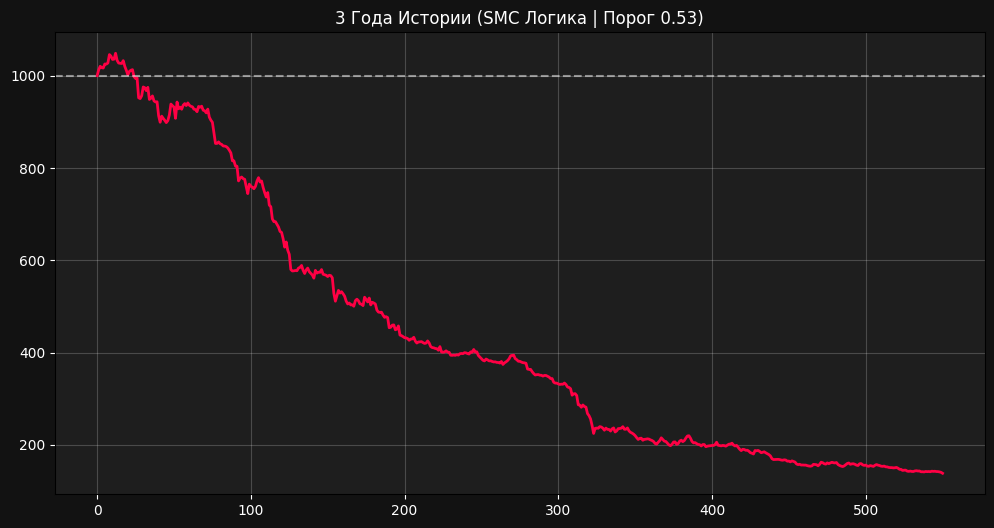

In [10]:
import matplotlib.pyplot as plt

print("📈 4. ХАРДКОРНЫЙ БЭКТЕСТЕР (Без заглядывания в будущее)...")

# Меняй только этот порог, чтобы проверять разные уровни агрессии бота
threshold = 0.53

test_probas = model.predict_proba(X_test)[:, 1]
signals = np.zeros(len(test_probas))
signals[test_probas >= threshold] = 1

start_balance = 1000.0
fee_pct = 0.0015 # Комиссия (0.15% в обе стороны с учетом микро-проскальзывания)
balance = start_balance
equity_curve = [balance]

in_position = False
exit_bar = 0
entry_price = 0.0
wins, losses = 0, 0

actual_prices = prices_test.values
hold_array = hold_times_test.values
max_idx = len(actual_prices) - 1

for i in range(len(signals)):
    if in_position:
        if i >= exit_bar:
            # ЗАКРЫВАЕМ СДЕЛКУ (Точно через 24 свечи, как училась модель)
            exit_price = actual_prices[min(i, max_idx)]
            price_change = (exit_price - entry_price) / entry_price
            net_trade_pct = price_change - (fee_pct * 2)
            
            balance += balance * net_trade_pct
            equity_curve.append(balance)
            
            if net_trade_pct > 0: wins += 1
            else: losses += 1
            
            in_position = False
        else:
            continue # Сидим в сделке, ждем
            
    # ОТКРЫВАЕМ СДЕЛКУ
    if not in_position and signals[i] == 1:
        in_position = True
        entry_price = actual_prices[i]
        exit_bar = i + int(hold_array[i]) # Берем hold_time из базы

total_trades = wins + losses

if total_trades == 0:
    print("⚠️ При таком пороге бот не нашел сделок.")
else:
    winrate = wins / total_trades
    net_profit = balance - start_balance
    roi = (net_profit / start_balance) * 100
    
    eq_series = pd.Series(equity_curve)
    max_drawdown = ((eq_series.cummax() - eq_series) / eq_series.cummax()).max() * 100
    
    print(f"📊 Сделок: {total_trades}")
    print(f"🎯 Винрейт (с учетом комсы): {winrate*100:.1f}% ({wins} П / {losses} М)")
    print(f"💵 Баланс: ${balance:.2f} (Профит: ${net_profit:.2f})")
    print(f"📈 ROI: {roi:.2f}%")
    print(f"📉 Макс. просадка: {max_drawdown:.2f}%")
    
    plt.figure(figsize=(12, 6))
    line_color = '#00ff88' if roi >= 0 else '#ff0044'
    plt.plot(equity_curve, color=line_color, linewidth=2)
    plt.axhline(start_balance, color='white', linestyle='--', alpha=0.5)
    plt.title(f"3 Года Истории (SMC Логика | Порог {threshold})", color='white')
    ax = plt.gca()
    ax.set_facecolor('#1e1e1e')
    plt.gcf().patch.set_facecolor('#121212')
    ax.tick_params(colors='white')
    plt.grid(True, alpha=0.2, color='white')
    plt.show()